### Notebook 1, ABNB

In [31]:
import polars as pl
import numpy as nu
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import altair as alt

In [32]:
# Config del estilo visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
print("Librerias importadas")

Librerias importadas


In [33]:
import requests

url = "https://data.insideairbnb.com/mexico/df/mexico-city/2026-06-15/data/listings.csv.gz"
file_name = "listings.csv.gz"

print("Descargando dataset...")
try:
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    with open(file_name, 'wb') as f:
        f.write(response.content)
    print("Descarga completa con exito.")
    
    df = pl.read_csv(file_name)
    print("Dataset cargado bien")
except Exception as e:
    print(f"Error al cargar el dataset: {e}")

# Limpieza inicial

if not df.is_empty():
    df = df.with_columns(
        pl.col("price")
        .str.replace_all(r"\$", "")
        .str.replace_all(r",", "")
        .cast(pl.Float64, strict = False)
        .alias("price")
    ).drop_nulls(subset = ["price"]).filter(pl.col("price") > 0)

display(df.head())

Descargando dataset...
Descarga completa con exito.
Dataset cargado bien


id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,…,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
i64,str,i64,str,str,str,str,str,str,i64,str,i64,str,str,str,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,f64,…,i64,i64,i64,i64,i64,f64,f64,str,str,i64,i64,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,i64,i64,i64,i64,f64
1698274831948209016,"""https://www.airbnb.com/rooms/1…",20260615212254,"""2026-06-16""","""city scrape""","""Roma Residence | Luxury Suite …","""Discover Condesa Residence Lux…",null,"""https://a0.muscache.com/pictur…",471105419,"""https://www.airbnb.com/users/s…",1470124798213804330,"""https://www.airbnb.com/users/p…","""Manuel""",null,3,10,3,10,"""Mexico City, Mexico""","""Para mí será un placer ser tu …",null,null,null,"""t""",null,"""https://a0.muscache.com/im/pic…",null,42,null,"""None""","""t""","""t""",null,"""Cuauhtémoc""",null,19.406572,…,365,1,2,365,365,1.0,365.0,null,"""t""",30,60,90,365,"""2026-06-16""",0,0,0,199,0,0,0,null,null,null,null,null,null,null,null,null,null,null,42,42,0,0,null
1120444645818769896,"""https://www.airbnb.com/rooms/1…",20260615212254,"""2026-06-17""","""city scrape""","""Grande y bonita habitación con…","""Disconnect from your worries i…",null,"""https://a0.muscache.com/pictur…",548898239,"""https://www.airbnb.com/users/s…",1470455484134025896,"""https://www.airbnb.com/users/p…","""Catu""",null,2,6,2,2,"""Mexico City, Mexico""",null,null,null,null,"""f""",null,"""https://a0.muscache.com/im/pic…",null,1,null,"""None""","""t""","""t""",null,"""Benito Juárez""",null,19.394448,…,365,1,1,365,365,1.0,365.0,null,"""t""",17,47,77,257,"""2026-06-17""",0,0,0,185,0,0,0,null,null,null,null,null,null,null,null,null,null,null,1,1,0,0,null
1414477907775396874,"""https://www.airbnb.com/rooms/1…",20260615212254,"""2026-06-17""","""city scrape""","""Ven a sentirte como en casa.""","""Relax with the whole family at…",null,"""https://a0.muscache.com/pictur…",49281983,"""https://www.airbnb.com/users/s…",1465750516819044639,"""https://www.airbnb.com/users/p…","""Mireya""",null,10,7,10,6,"""Mexico City, Mexico""","""Persona amigable, atenta, gust…",null,null,null,"""f""",null,"""https://a0.muscache.com/im/pic…",null,2,null,"""None""","""t""","""t""",null,"""Coyoacán""",null,19.339362,…,365,1,1,365,365,1.0,365.0,null,"""t""",0,0,0,158,"""2026-06-17""",0,0,0,0,0,0,0,null,null,null,null,null,null,null,null,null,null,null,2,0,2,0,null
1298027147444763745,"""https://www.airbnb.com/rooms/1…",20260615212254,"""2026-06-17""","""city scrape""","""Habitación pequeña 16""","""You'll be close to everything …",null,"""https://a0.m

In [34]:
# Analisis basico
print("1. Cual es el precio promedio por noche?")
avg_price = df.select(pl.col('price').mean()).item()
print(f'El precio promedio por noche es: {avg_price}')
print('2. Cuales son los tipos de alojamiento?')
room_types = df.group_by('room_type').agg(pl.len().alias('count')).sort('count', descending=True)
display(room_types)
print('Cuales son las 10 alcaldias con mas alojamiento')
top_10_alcaldias = df.group_by('neighbourhood_cleansed').agg(pl.len().alias('count')).sort('count', descending=True).head(10)
display(top_10_alcaldias)


1. Cual es el precio promedio por noche?
El precio promedio por noche es: 2913.6942251240002
2. Cuales son los tipos de alojamiento?


room_type,count
str,u32
"""Entire home/apt""",19856
"""Private room""",9407
"""Shared room""",291
"""Hotel room""",83


Cuales son las 10 alcaldias con mas alojamiento


neighbourhood_cleansed,count
str,u32
"""Cuauhtémoc""",13683
"""Miguel Hidalgo""",4540
"""Benito Juárez""",3373
"""Coyoacán""",2334
"""Tlalpan""",1064
"""Venustiano Carranza""",1022
"""Álvaro Obregón""",974
"""Iztacalco""",569
"""Gustavo A. Madero""",531


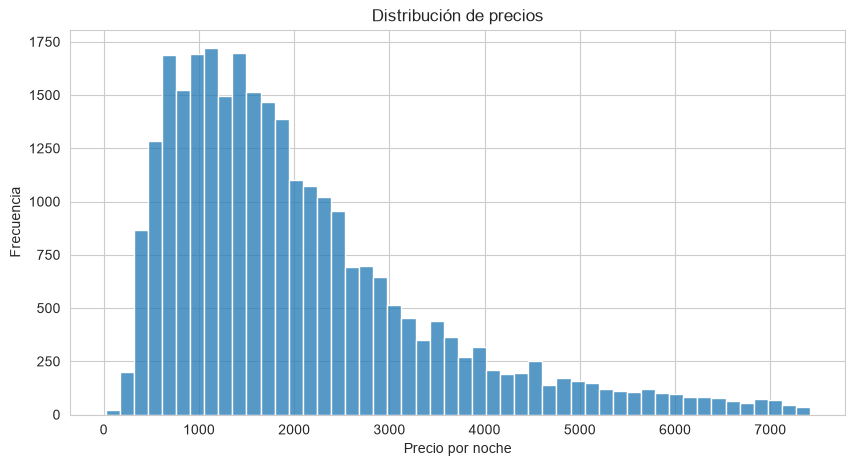

In [35]:
# Visualizaciones
price_to_plot_df = df.filter(pl.col("price") < df.select(pl.col("price").quantile(0.95)).item()).to_pandas()

plt.figure(figsize=(10, 5))
sns.histplot(data=price_to_plot_df, x="price", bins=50)
plt.title("Distribución de precios")
plt.xlabel("Precio por noche")
plt.ylabel("Frecuencia")
plt.show()